<center> <h1> Google Data-Driven Insights into Play Store Apps</h1> </center>

In [2]:
from IPython.display import Image
Image("header.png")

In [3]:
#Import required libraries:
import pandas as pd
import seaborn as sns
import numpy as np


from statsmodels.stats.weightstats import ztest # for z-test
from scipy.stats import ttest_ind  # for t-test
from scipy.stats import f_oneway # for anova
from scipy.stats import chi2_contingency # for chi-square



#Ignore all incoming warnings (if any):
import warnings
warnings.filterwarnings("ignore")

In [4]:
#Load the dataset:
df = pd.read_csv("dataset/googleplaystore.csv")

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
df.shape

(10841, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [8]:
df["Category"].value_counts()

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

## Data cleaning:

In [9]:

# Remove wrong row where Category is invalid
df = df[df["Category"] != "1.9"]

# Remove duplicate apps
df = df.drop_duplicates(subset="App", keep="first")

# Convert Reviews to numeric
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Clean Installs column
df["Installs"] = (
    df["Installs"]
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Clean Price column
df["Price"] = (
    df["Price"]
    .str.replace("$", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [10]:
# Clean Size column

def clean_size(size):
    if pd.isna(size):
        return np.nan
    
    size = str(size)
    
    if size == "Varies with device":
        return np.nan
    
    if "M" in size:
        return float(size.replace("M", ""))
    
    if "k" in size:
        return float(size.replace("k", "")) / 1024
    
    return np.nan

df["Size_MB"] = df["Size"].apply(clean_size)

In [11]:
# Convert Last Updated to datetime
df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

# Fill missing values
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Size_MB"] = df["Size_MB"].fillna(df["Size_MB"].median())
df["Type"] = df["Type"].fillna(df["Type"].mode()[0])
df["Content Rating"] = df["Content Rating"].fillna(df["Content Rating"].mode()[0])
df["Current Ver"] = df["Current Ver"].fillna("Unknown")
df["Android Ver"] = df["Android Ver"].fillna("Unknown")

# Final check
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Size_MB           0
dtype: int64

## Feature Engineering:


In [12]:
# App name length
df["App_Name_Length"] = df["App"].apply(len)

# Number of genres
df["Genre_Count"] = df["Genres"].apply(lambda x: len(str(x).split(";")))

# Main genre
df["Main_Genre"] = df["Genres"].apply(lambda x: str(x).split(";")[0])

# Free or Paid as numeric
df["Is_Free"] = df["Type"].apply(lambda x: 1 if x == "Free" else 0)

# Log transformation for skewed columns
df["Log_Reviews"] = np.log1p(df["Reviews"])
df["Log_Installs"] = np.log1p(df["Installs"])
df["Log_Price"] = np.log1p(df["Price"])

# Days since last update
latest_date = df["Last Updated"].max()
df["Days_Since_Update"] = (latest_date - df["Last Updated"]).dt.days

# Rating category
def rating_group(rating):
    if rating >= 4.5:
        return "Excellent"
    elif rating >= 4.0:
        return "Good"
    elif rating >= 3.0:
        return "Average"
    else:
        return "Poor"

df["Rating_Group"] = df["Rating"].apply(rating_group)
df["Main_Genre"] = df["Genres"].apply(lambda x: str(x).split(";")[0])

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Size_MB,App_Name_Length,Genre_Count,Main_Genre,Is_Free,Log_Reviews,Log_Installs,Log_Price,Days_Since_Update,Rating_Group
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,...,19.0,46,1,Art & Design,1,5.075174,9.210440,0.0,213,Good
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,...,14.0,19,2,Art & Design,1,6.875232,13.122365,0.0,205,Average
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,...,8.7,50,1,Art & Design,1,11.379520,15.424949,0.0,7,Excellent
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,...,25.0,21,1,Art & Design,1,12.281389,17.727534,0.0,61,Excellent
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,...,2.8,37,2,Art & Design,1,6.875232,11.512935,0.0,49,Good


In [13]:
clean_df = df.copy()

clean_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Size_MB,App_Name_Length,Genre_Count,Main_Genre,Is_Free,Log_Reviews,Log_Installs,Log_Price,Days_Since_Update,Rating_Group
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,...,19.0,46,1,Art & Design,1,5.075174,9.210440,0.0,213,Good
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,...,14.0,19,2,Art & Design,1,6.875232,13.122365,0.0,205,Average
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,...,8.7,50,1,Art & Design,1,11.379520,15.424949,0.0,7,Excellent
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,...,25.0,21,1,Art & Design,1,12.281389,17.727534,0.0,61,Excellent
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,...,2.8,37,2,Art & Design,1,6.875232,11.512935,0.0,49,Good


## Exploratory Data Analytics:

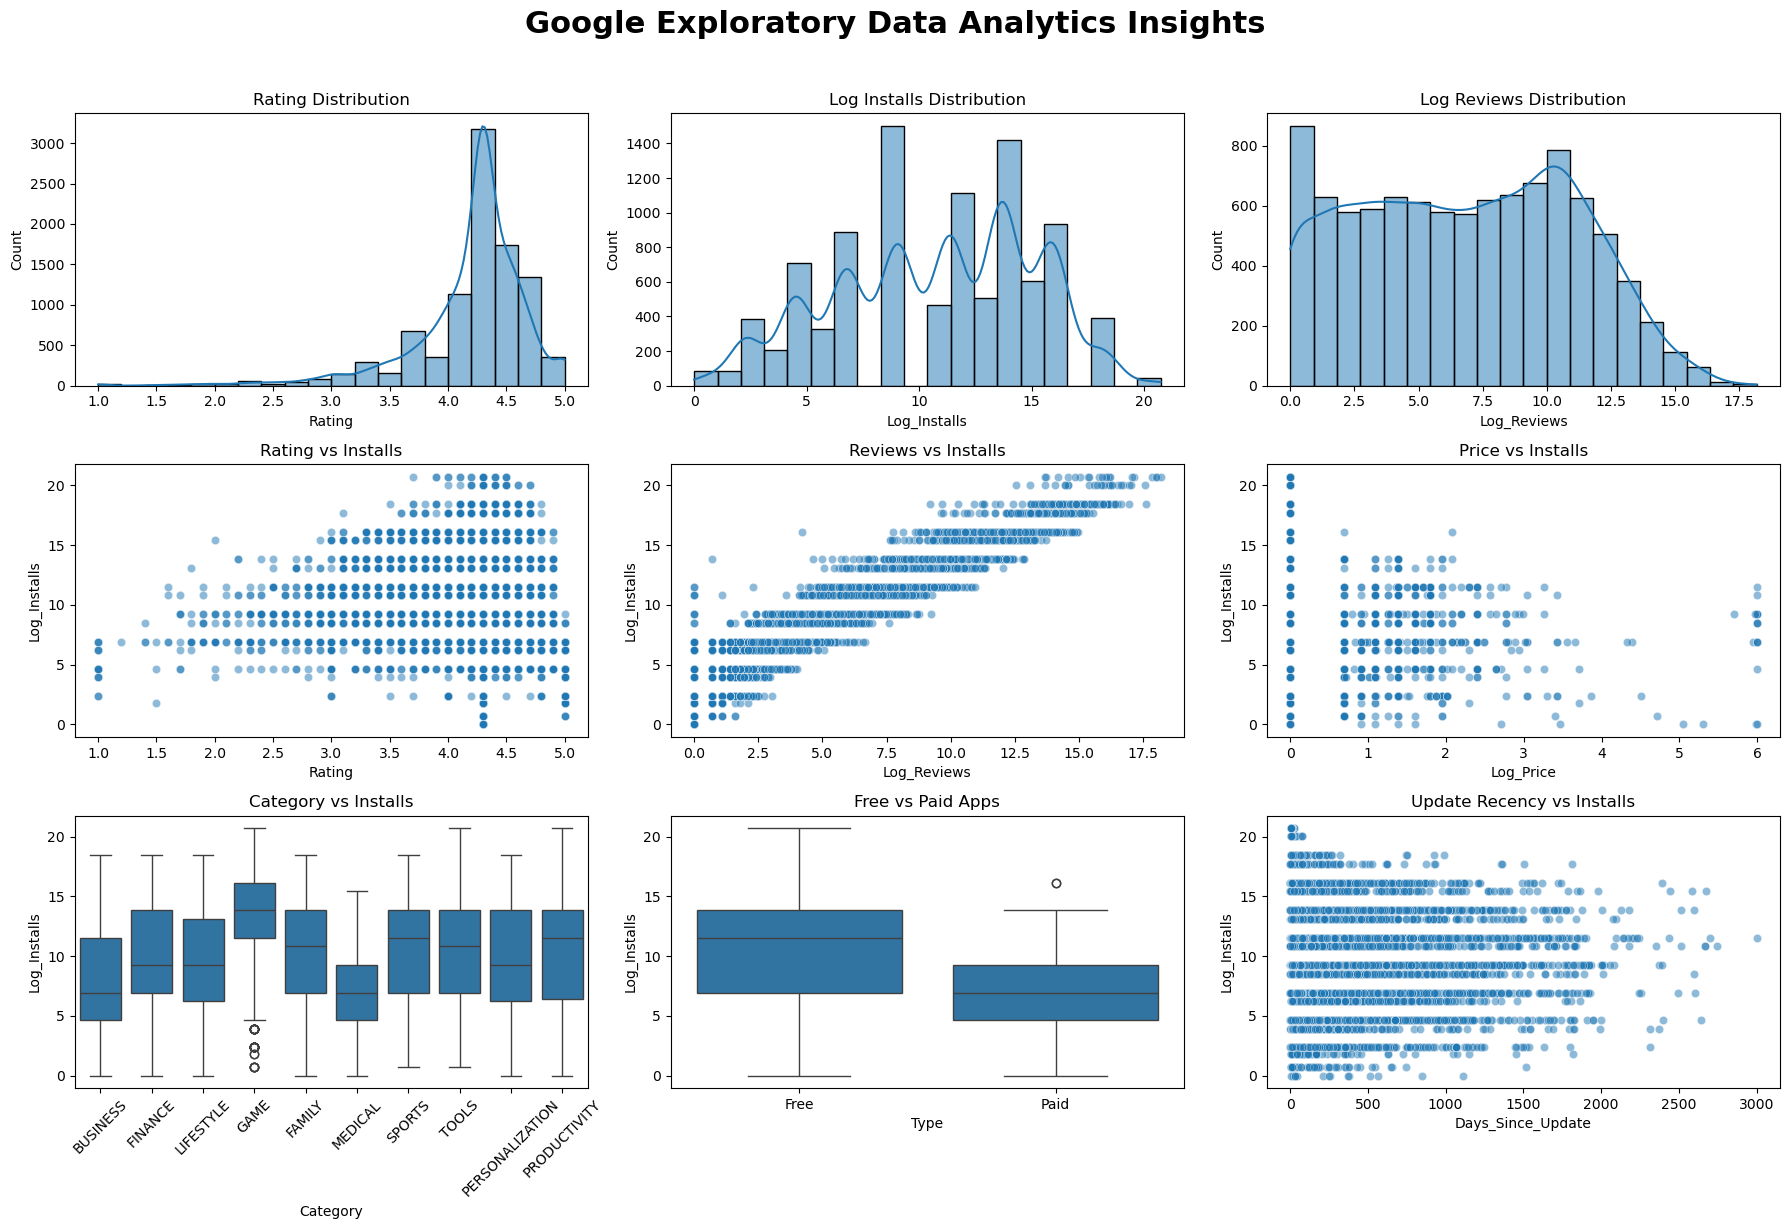

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

plt.suptitle(
    "Google Exploratory Data Analytics Insights",
    fontsize=22,
    fontweight="bold",
    color="black",
    y=1.02
)


# 1. Rating Distribution
plt.subplot(3, 3, 1)
sns.histplot(clean_df["Rating"], bins=20, kde=True)
plt.title("Rating Distribution")

# 2. Installs Distribution (Log)
plt.subplot(3, 3, 2)
sns.histplot(clean_df["Log_Installs"], bins=20, kde=True)
plt.title("Log Installs Distribution")

# 3. Reviews Distribution (Log)
plt.subplot(3, 3, 3)
sns.histplot(clean_df["Log_Reviews"], bins=20, kde=True)
plt.title("Log Reviews Distribution")

# 4. Rating vs Installs
plt.subplot(3, 3, 4)
sns.scatterplot(x="Rating", y="Log_Installs", data=clean_df, alpha=0.5)
plt.title("Rating vs Installs")

# 5. Reviews vs Installs
plt.subplot(3, 3, 5)
sns.scatterplot(x="Log_Reviews", y="Log_Installs", data=clean_df, alpha=0.5)
plt.title("Reviews vs Installs")

# 6. Price vs Installs
plt.subplot(3, 3, 6)
sns.scatterplot(x="Log_Price", y="Log_Installs", data=clean_df, alpha=0.5)
plt.title("Price vs Installs")

# 7. Category vs Installs (Top 10 categories only)
plt.subplot(3, 3, 7)
top_categories = clean_df["Category"].value_counts().index[:10]
sns.boxplot(x="Category", y="Log_Installs", data=clean_df[clean_df["Category"].isin(top_categories)])
plt.xticks(rotation=45)
plt.title("Category vs Installs")

# 8. Free vs Paid Apps
plt.subplot(3, 3, 8)
sns.boxplot(x="Type", y="Log_Installs", data=clean_df)
plt.title("Free vs Paid Apps")

# 9. Days Since Update vs Installs
plt.subplot(3, 3, 9)
sns.scatterplot(x="Days_Since_Update", y="Log_Installs", data=clean_df, alpha=0.5)
plt.title("Update Recency vs Installs")

plt.tight_layout()
plt.show()

## Design and Export Machine Learning models to:
### Q1] Predict the expected number of installs for a Google Play Store app based on its category, rating, number of reviews, size, price, content rating, genre, and update history.

### Q2] Classify whether an app will become a high-performing app based on its rating, reviews, category, price, size, content rating, genre, and update frequency.

<br>


## Check for these claims to be true or false:

## Z-TEST:
### Q3] Google wants to determine whether the average rating of apps on the Play Store is significantly greater than 4.2 .
### Q4] Google wants to determine whether the average app size on the Play Store is significantly lower than the industry benchmark of 25 MB after introducing new app optimization guidelines.
### Q5] Google wants to determine whether the average price of paid apps on the Play Store is significantly different from the industry benchmark price of $5.

## T-TEST:
### Q6] Google wants to determine whether there is a significant difference in the average ratings of free apps and paid apps on the Google Play Store.

## ANOVA:
### Q7] Google wants to determine whether the average app ratings differ significantly across different app categories on the Google Play Store.

## CHI-SQUARE:
### Q8] Google wants to determine whether app type (Free or Paid) is associated with app content rating (Everyone, Teen, Mature 17+, etc.).

<center> <h3> Question 1 </h3> </center>

In [15]:

y = clean_df["Log_Installs"]

In [16]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   App                9659 non-null   object        
 1   Category           9659 non-null   object        
 2   Rating             9659 non-null   float64       
 3   Reviews            9659 non-null   int64         
 4   Size               9659 non-null   object        
 5   Installs           9659 non-null   int64         
 6   Type               9659 non-null   object        
 7   Price              9659 non-null   float64       
 8   Content Rating     9659 non-null   object        
 9   Genres             9659 non-null   object        
 10  Last Updated       9659 non-null   datetime64[ns]
 11  Current Ver        9659 non-null   object        
 12  Android Ver        9659 non-null   object        
 13  Size_MB            9659 non-null   float64       
 14  App_Name_Len

In [17]:
from sklearn.model_selection import train_test_split

X = clean_df[["Category","Rating","Reviews","Size","Price","Content Rating","Main_Genre","Last Updated"]]
y = clean_df["Log_Installs"]


X_train , X_test , y_train , y_test = train_test_split(
    X , y, test_size=0.2, random_state=42)


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)])

In [18]:
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    SGDRegressor
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor)

regression_pipelines = {
    
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    
    "Ridge Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]),
    
    "Lasso Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", Lasso())
    ]),
    
    "ElasticNet Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ElasticNet())
    ]),
    
    "SGD Regressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SGDRegressor(random_state=42, max_iter=1000))
    ]),
    
    "KNN Regressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]),
    
    "SVR": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVR())
    ]),
    
    "Decision Tree Regressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    
    "Random Forest Regressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]),
    
    "Extra Trees Regressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesRegressor(random_state=42))
    ]),
    
    "Gradient Boosting Regressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
    
    "AdaBoost Regressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", AdaBoostRegressor(random_state=42))
    ]),
    
    "Bagging Regressor": Pipeline([
        ("preprocessor", preprocessor),
        ("model", BaggingRegressor(random_state=42))
    ])
}

In [19]:
#Train and Evaluate All Models:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


results = []

for name, pipeline in regression_pipelines.items():
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="R2 Score", ascending=False)

results_df

,Model,MAE,MSE,RMSE,R2 Score
10,Gradient Boosting Regressor,0.760121,1.036287,1.017982,0.947522
8,Random Forest Regressor,0.756879,1.113089,1.055030,0.943633
12,Bagging Regressor,0.768421,1.171365,1.082296,0.940682
9,Extra Trees Regressor,0.780540,1.231751,1.109843,0.937624
11,AdaBoost Regressor,0.969700,1.523969,1.234492,0.922826
7,Decision Tree Regressor,0.864766,1.787361,1.336922,0.909487
5,KNN Regressor,2.011126,7.371981,2.715139,0.626680
6,SVR,2.633036,11.543997,3.397646,0.415408
1,Ridge Regression,3.006052,13.886832,3.726504,0.296766
4,SGD Regressor,3.056396,13.925781,3.731726,0.294793


In [20]:
#Cross Validation for all models:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

cv_results = []

for name, pipeline in regression_pipelines.items():
    
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring
    )
    
    cv_results.append({
        "Model": name,
        "CV R2": scores["test_r2"].mean(),
        "CV MAE": -scores["test_mae"].mean(),
        "CV MSE": -scores["test_mse"].mean(),
        "CV RMSE": -scores["test_rmse"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(by="CV R2", ascending=False)

cv_results_df

,Model,CV R2,CV MAE,CV MSE,CV RMSE
10,Gradient Boosting Regressor,0.942916,0.782514,1.091069,1.044354
8,Random Forest Regressor,0.939200,0.776127,1.161900,1.077741
12,Bagging Regressor,0.935191,0.797872,1.238560,1.112649
9,Extra Trees Regressor,0.931382,0.802600,1.310621,1.144654
11,AdaBoost Regressor,0.916188,0.988799,1.601479,1.264925
7,Decision Tree Regressor,0.901631,0.886368,1.880097,1.370870
5,KNN Regressor,0.605200,2.038732,7.540012,2.745216
6,SVR,0.391132,2.634548,11.638276,3.411215
1,Ridge Regression,0.270561,3.018469,13.943497,3.733840
0,Linear Regression,0.267131,3.021494,14.009384,3.742647


In [21]:
#Hyper paramter tuning on Gradient Boosting Regressor:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=regression_pipelines["Gradient Boosting Regressor"],
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Rating', 'Reviews', 'Price'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Category', 'Size', 'Content Rating', 'Main_Genre'], dtype='object'))])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [22]:
#Get Best Paramters and Best CV Score:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV R2 Score:")
print(grid_search.best_score_)



#Select Best Model:
best_pipeline = grid_search.best_estimator_

best_pipeline.fit(X_train, y_train)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best CV R2 Score:
0.9417227357446663


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Rating', 'Reviews', 'Price'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Category', 'Size', 'Content Rating', 'Main_Genre'], dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(min_samples_leaf=2,
                                           min_samples_split=5,
                                           random_state=42))])

In [23]:
#Make final prediction:
y_pred_best = best_pipeline.predict(X_test)

#Final Evaluation:
print("Best Model:", best_pipeline)
print()

print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2 Score:", r2_score(y_test, y_pred_best))

Best Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Rating', 'Reviews', 'Price'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Category', 'Size', 'Content Rating', 'Main_Genre'], dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(min_samples_leaf=2,
                                           min_samples_split=5,
                                           random_state=42))])

MAE: 0.7577793571323872
MSE: 1.0317638695189377
RMSE: 1.0157577809295568
R2 Score: 0.9477511000563719


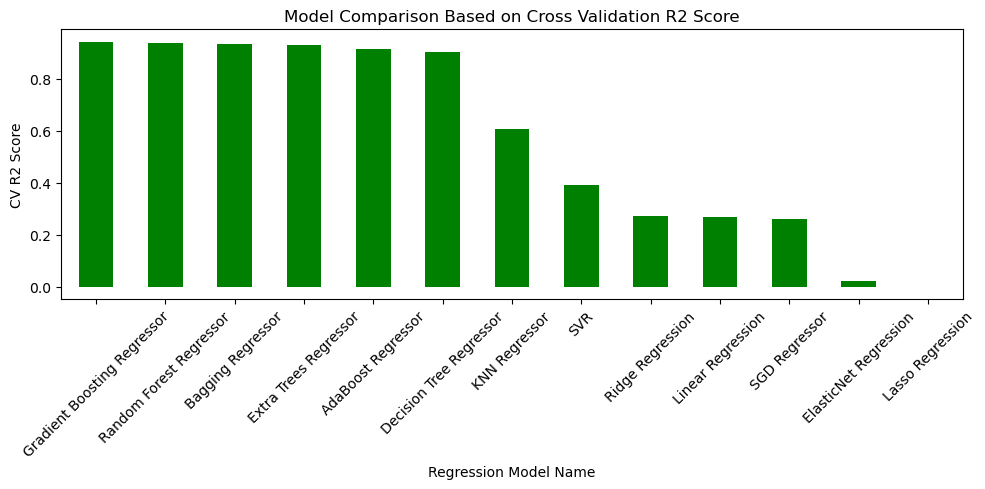

In [24]:
#Perform model comparison:
plt.figure(figsize=(10, 5))

cv_results_df.set_index("Model")["CV R2"].plot(
    kind="bar",
    color="green"
)

plt.title("Model Comparison Based on Cross Validation R2 Score")
plt.xlabel("Regression Model Name")
plt.ylabel("CV R2 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
#Export the model:
import joblib
joblib.dump(best_pipeline,"AppInstalls_PredictionModel.pkl")

['AppInstalls_PredictionModel.pkl']

<center> <h3> Question 2 </h3> </center>

In [26]:

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier
)
from sklearn.naive_bayes import GaussianNB

In [27]:
clean_df["High_Performing_App"] = np.where(
    clean_df["Installs"] >= 1000000,
    1,
    0
)

clean_df["High_Performing_App"].value_counts()

High_Performing_App
0    6264
1    3395
Name: count, dtype: int64

In [28]:
X = clean_df[
    [
        "Category",
        "Size_MB",
        "Price",
        "Content Rating",
        "Main_Genre",
        "Days_Since_Update",
        "App_Name_Length",
        "Genre_Count",
        "Is_Free",
        "Log_Price"
    ]
]

y = clean_df["High_Performing_App"]

print(y.value_counts())


num_cols = [
    "Size_MB",
    "Price",
    "Days_Since_Update",
    "App_Name_Length",
    "Genre_Count",
    "Is_Free",
    "Log_Price"
]

cat_cols = [
    "Category",
    "Content Rating",
    "Main_Genre"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

High_Performing_App
0    6264
1    3395
Name: count, dtype: int64


In [29]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:

classification_pipelines = {

    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "SGD Classifier": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SGDClassifier(random_state=42))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVC": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC())
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),

    "Extra Trees": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(random_state=42))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),

    "AdaBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", AdaBoostClassifier(random_state=42))
    ]),

    "Bagging": Pipeline([
        ("preprocessor", preprocessor),
        ("model", BaggingClassifier(random_state=42))
    ]),

    "Naive Bayes": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GaussianNB())
    ])
}

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, pipe in classification_pipelines.items():

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1
5,Random Forest,0.786749,0.725888,0.631811,0.675591
6,Extra Trees,0.772774,0.700000,0.618557,0.656763
7,Gradient Boosting,0.782091,0.741573,0.583211,0.652927
8,AdaBoost,0.769669,0.717472,0.568483,0.634347
3,SVC,0.768634,0.723938,0.552283,0.626566
9,Bagging,0.761387,0.698182,0.565538,0.624898
2,KNN,0.745859,0.650160,0.599411,0.623755
4,Decision Tree,0.734472,0.626911,0.603829,0.615154
10,Naive Bayes,0.530021,0.422583,0.920471,0.579240
0,Logistic Regression,0.740166,0.676647,0.499264,0.574576


In [32]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = []

for name, pipe in classification_pipelines.items():

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV F1", ascending=False)
cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1
5,Random Forest,0.778445,0.706248,0.633873,0.667884
7,Gradient Boosting,0.778549,0.729041,0.589691,0.651821
6,Extra Trees,0.765192,0.682305,0.621797,0.650512
2,KNN,0.746350,0.646033,0.616495,0.630805
9,Bagging,0.755564,0.683121,0.568483,0.620455
8,AdaBoost,0.750182,0.666703,0.578792,0.619577
3,SVC,0.753597,0.691609,0.540795,0.606642
4,Decision Tree,0.719536,0.600671,0.604418,0.602310
10,Naive Bayes,0.546122,0.430089,0.893667,0.580482
0,Logistic Regression,0.732373,0.659536,0.493962,0.564752


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=classification_pipelines["Gradient Boosting"],
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Size_MB',
                                                                          'Price',
                                                                          'Days_Since_Update',
                                                                          'App_Name_Length',
                                                                          'Genre_Count',
                                                                          'Is_Free',
                                                                          'Log_Price']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['Category',
                                                                          'Content '
                                                                          'Rating',
                                                                          'Main_Genre'])])),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1', verbose=2)

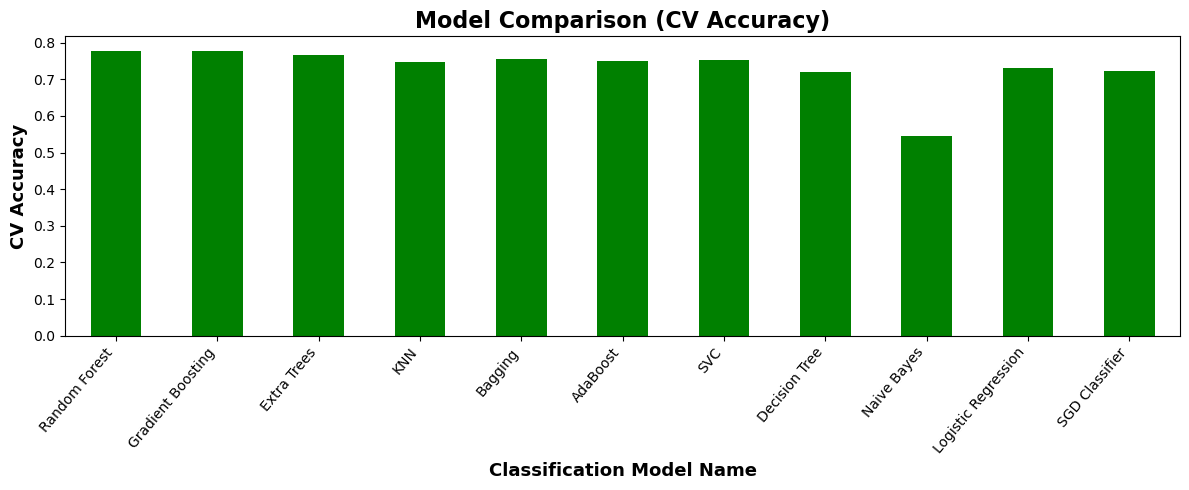

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

cv_results_df.set_index("Model")["CV Accuracy"].plot(
    kind="bar",
    color="green"
)

plt.title("Model Comparison (CV Accuracy)", fontsize=16, fontweight="bold", color="black")
plt.xlabel("Classification Model Name", fontsize=13, fontweight="bold", color="black")
plt.ylabel("CV Accuracy", fontsize=13, fontweight="bold", color="black")

plt.xticks(rotation=50, ha="right")
plt.tight_layout()
plt.show()

In [35]:
# Select Best Model
best_pipeline = grid_search.best_estimator_
best_pipeline.fit(X_train, y_train)


#Export the model:
import joblib
joblib.dump(best_pipeline, "AppPerformancePrediction.pkl")

['AppPerformancePrediction.pkl']

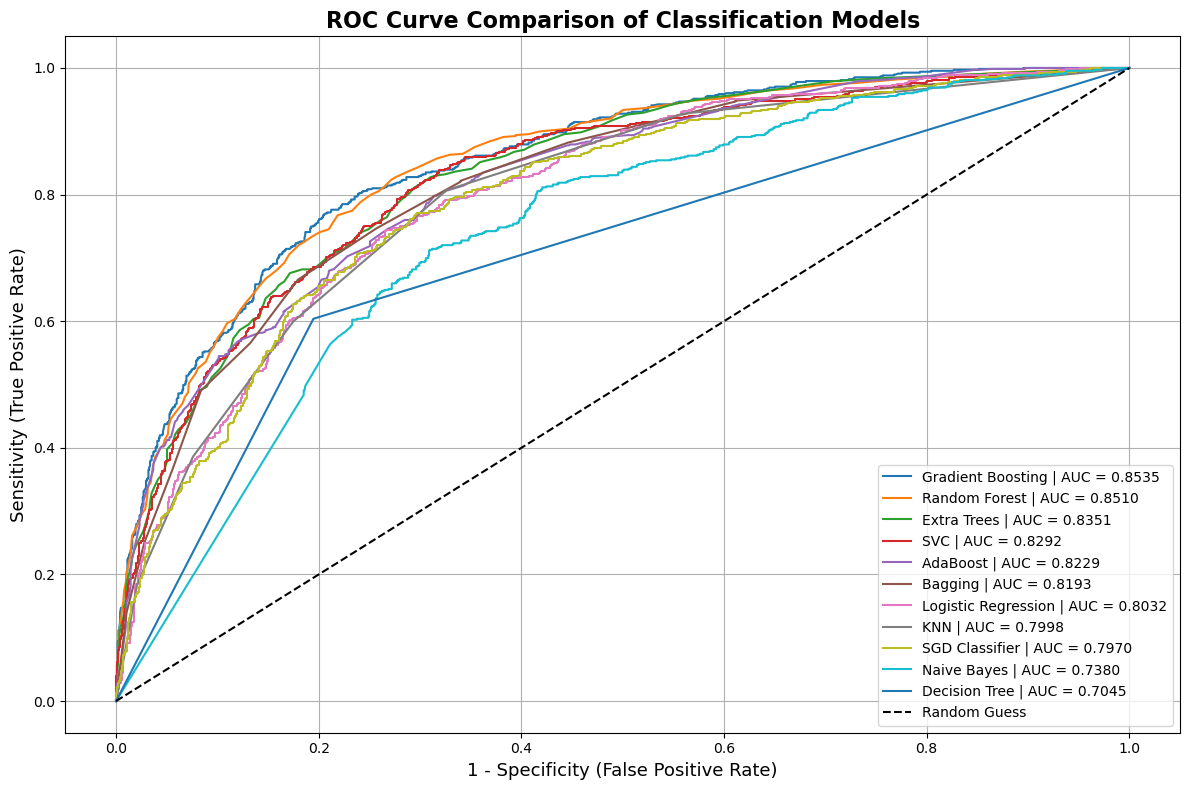

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

roc_results = []

# Train and collect ROC data
for model_name, pipeline in classification_pipelines.items():

    pipeline.fit(X_train, y_train)

    # Get prediction scores
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]

    elif hasattr(pipeline.named_steps["model"], "decision_function"):
        y_score = pipeline.decision_function(X_test)

    else:
        print(f"{model_name} skipped")
        continue

    # ROC metrics
    fpr, tpr, thresholds = roc_curve(y_test, y_score)

    auc_score = roc_auc_score(y_test, y_score)

    roc_results.append({
        "Model": model_name,
        "AUC": auc_score,
        "FPR": fpr,
        "TPR": tpr
    })

# Sort by highest AUC
roc_results = sorted(
    roc_results,
    key=lambda x: x["AUC"],
    reverse=True
)

# Plot ROC Curves
plt.figure(figsize=(12, 8))

for result in roc_results:

    plt.plot(
        result["FPR"],
        result["TPR"],
        label=f"{result['Model']} | AUC = {result['AUC']:.4f}"
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random Guess"
)

plt.title(
    "ROC Curve Comparison of Classification Models",
    fontsize=16,
    fontweight="bold"
)

# Statistical labels
plt.xlabel(
    "1 - Specificity (False Positive Rate)",
    fontsize=13
)

plt.ylabel(
    "Sensitivity (True Positive Rate)",
    fontsize=13
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.grid(True)

plt.tight_layout()
plt.show()

<center> <h3> Question 3 </h3> </center>

In [37]:


alpha = 0.05

population_mean = 4.2

sample_data = clean_df["Rating"]

z_stat, p_value = ztest(
    sample_data,
    value=population_mean,
    alternative="larger"
)


if p_value < alpha:
    
    print("\nReject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "The average app rating on Google Play Store "
        "is significantly greater than 4.2."
    )

else:
    
    print("\nFail to Reject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "There is insufficient evidence that "
        "the average app rating exceeds 4.2."
    )


Fail to Reject Null Hypothesis
Business Conclusion: There is insufficient evidence that the average app rating exceeds 4.2.


<center> <h3> Question 4 </h3> </center>

In [38]:


alpha = 0.05

population_mean = 25


sample_data = clean_df["Size_MB"]

z_stat, p_value = ztest(
    sample_data,
    value=population_mean,
    alternative="smaller"
)


if p_value < alpha:
    
    print("\nReject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "Average app size on the Play Store is significantly lower "
        "than the industry benchmark of 25 MB after introducing "
        "new app optimization guidelines."
    )

else:
    
    print("\nFail to Reject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "Average app size on the Play Store is not significantly "
        "lower than the industry benchmark of 25 MB after "
        "introducing new app optimization guidelines."
    )


Reject Null Hypothesis
Business Conclusion: Average app size on the Play Store is significantly lower than the industry benchmark of 25 MB after introducing new app optimization guidelines.


<center> <h3> Question 5 </h3> </center>

In [39]:


alpha = 0.05

population_mean = 5


sample_data = clean_df["Price"]

z_stat, p_value = ztest(
    sample_data,
    value=population_mean,
    alternative="two-sided"
)


if p_value < alpha:
    
    print("\nReject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "The average price of paid apps on the Google Play Store "
        "is significantly different from the industry benchmark price of $5."
    )

else:
    
    print("\nFail to Reject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "The average price of paid apps on the Google Play Store "
        "is not significantly different from the industry benchmark price of $5."
    )


Reject Null Hypothesis
Business Conclusion: The average price of paid apps on the Google Play Store is significantly different from the industry benchmark price of $5.


<center> <h3> Question 6 </h3> </center>

In [40]:

alpha = 0.05

free_apps = clean_df[
    clean_df["Type"] == "Free"
]["Rating"].dropna()

paid_apps = clean_df[
    clean_df["Type"] == "Paid"
]["Rating"].dropna()


# Independent Two Sample T-Test
t_stat, p_value = ttest_ind(
    free_apps,
    paid_apps,
    equal_var=False
)


if p_value < alpha:
    
    print("\nReject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "There is a significant difference between "
        "the average ratings of free and paid apps "
        "on the Google Play Store."
    )

else:
    
    print("\nFail to Reject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "There is no significant difference between "
        "the average ratings of free and paid apps "
        "on the Google Play Store."
    )


Reject Null Hypothesis
Business Conclusion: There is a significant difference between the average ratings of free and paid apps on the Google Play Store.


<center> <h3> Question 7 </h3> </center>

In [41]:

alpha = 0.05

top_categories = clean_df["Category"].value_counts().index[:5]

category_groups = []

for category in top_categories:
    
    ratings = clean_df[
        clean_df["Category"] == category
    ]["Rating"].dropna()
    
    category_groups.append(ratings)


f_stat, p_value = f_oneway(*category_groups)

print("F Statistic:", f_stat)
print("P Value:", p_value)

if p_value < alpha:
    
    print("\nReject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "Average app ratings differ significantly "
        "across Google Play Store categories."
    )

else:
    
    print("\nFail to Reject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "Average app ratings do not differ significantly "
        "across categories."
    )

F Statistic: 14.42741019324697
P Value: 1.0448388331715806e-11

Reject Null Hypothesis
Business Conclusion: Average app ratings differ significantly across Google Play Store categories.


<center> <h3> Question 8 </h3> </center>

In [42]:

alpha = 0.05

contingency_table = pd.crosstab(
    clean_df["Type"],
    clean_df["Content Rating"]
)

print(contingency_table)

chi_stat, p_value, dof, expected = chi2_contingency(
    contingency_table
)

if p_value < alpha:
    
    print("\nReject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "App Type and Content Rating are significantly associated "
        "on the Google Play Store."
    )

else:
    
    print("\nFail to Reject Null Hypothesis")
    
    print(
        "Business Conclusion: "
        "App Type and Content Rating are independent "
        "on the Google Play Store."
    )

Content Rating  Adults only 18+  Everyone  Everyone 10+  Mature 17+  Teen  \
Type                                                                        
Free                          3      7248           291         375   984   
Paid                          0       655            31          18    52   

Content Rating  Unrated  
Type                     
Free                  2  
Paid                  0  

Reject Null Hypothesis
Business Conclusion: App Type and Content Rating are significantly associated on the Google Play Store.


**Project by:** <br> <br>
**Name**: Om Satyawan Pathak <br>
**Email**: omsatyawanpathakgit@gmail.com (or) omsatyawanpathakwebdevelopment@gmail.com <br>
**LinkedIn Profile**: www.linkedin.com/in/om-satyawan-pathak-029b02368 <br>